**1. Project Overview**

**Title: Analysis of Trader Performance vs. Market Sentiment on Hyperliquid**

**Candidate:** Uvana Coutinho

**Hypothesis**:We hypothesize that extreme market sentiment leads to measurable behavioral changes in traders, affecting trade frequency, execution quality, and profitability.

**Objective:** This project evaluates whether trader profitability is driven more by market sentiment or by execution behavior, using granular transaction-level data combined with the Fear & Greed Index.

**Business Relevance:** Insights from this analysis can help trading platforms optimize user behavior through alerts, risk controls, and execution guidance.

**2. Data Acquisition & Audit**

**Phase 1: Data Loading and Initial Audit**
We begin by loading the historical_data.csv (Trader dataset) and the fear_greed_index.csv (Sentiment dataset).

**Data Audit:** We perform a high-level check to identify the number of unique accounts, the date range, and the presence of any missing values.

**Cleaning:** We focus on columns like Closed PnL, Size USD, Fee, and Timestamp IST for the trader side, and classification and value for the sentiment side.

In [ ]:
import pandas as pd
import numpy as np

# Load datasets
trader_df = pd.read_csv('/content/historical_data.csv')
sentiment_df = pd.read_csv('/content/fear_greed_index.csv')

# Audit Function
def audit_data(df, name):
    print(f"--- {name} Audit ---")
    print(f"Shape: {df.shape}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    if 'Account' in df.columns:
        print(f"Unique Accounts: {df['Account'].nunique()}")
    print("-" * 30)

audit_data(trader_df, "Trader Data")
audit_data(sentiment_df, "Sentiment Data")

--- Trader Data Audit ---
Shape: (211224, 16)
Missing Values: 0
Unique Accounts: 32
------------------------------
--- Sentiment Data Audit ---
Shape: (2644, 4)
Missing Values: 0
------------------------------


**Data Quality Note:**
Data quality checks confirmed no missing or duplicate records. However, due to the aggregation of transaction-level data into daily metrics, some intra-day behavioral patterns may not be fully captured.

**3. Feature Engineering & Alignment**

**Phase 2: Temporal Alignment and Net PnL Calculation**

As sentiment is recorded daily, we aggregate the transactional data to a Daily Performance Profile.

**Net PnL:** Calculated as Closed PnL minus Fee. This provides a realistic view of trader success after transaction costs.

**Temporal Standardization**: We convert Timestamp IST (Trader) and date (Sentiment) into uniform Python Date objects to allow for a precise inner join.

**Behavioral Metrics:** We derive trade_count (using unique Trade IDs) and total_volume to measure activity levels.

In [41]:

# 1. STANDARDIZE DATES

trader_df['Date'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True).dt.date
sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.date

# 2. AGGREGATE TRADER DATA

daily_stats = trader_df.groupby(['Account', 'Date']).agg(
    gross_pnl=('Closed PnL', 'sum'),
    Fee=('Fee', 'sum'),
    trade_count=('Trade ID', 'nunique'),
    total_volume=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    long_bias=('Side', lambda x: (x == 'BUY').mean())
).reset_index()

# Net PnL after fees
daily_stats['daily_net_pnl'] = daily_stats['gross_pnl'] - daily_stats['Fee']

# 3. MERGE WITH SENTIMENT DATA

df_master = pd.merge(
    daily_stats,
    sentiment_df[['Date', 'classification', 'value']],
    on='Date',
    how='inner'
)

# Profitability flag
df_master['is_profitable'] = df_master['daily_net_pnl'] > 0

# 4. FEATURE ENGINEERING

# Trading cost efficiency: identifies fee drag from high-frequency trading
df_master['fee_ratio'] = df_master['Fee'] / df_master['total_volume'].replace(0, np.nan)

# Trade effectiveness: evaluates profit generated per trade
df_master['pnl_per_trade'] = df_master['daily_net_pnl'] / df_master['trade_count'].replace(0, np.nan)

# 5. CLEAN SENTIMENT ORDER

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

df_master['classification'] = pd.Categorical(
    df_master['classification'],
    categories=sentiment_order,
    ordered=True
)

# 6. QUICK VALIDATION

print(df_master.head())
print(df_master.describe())

# 7 CHECK RELATIONSHIPS

print(
    df_master.groupby('classification')[['trade_count', 'Fee', 'daily_net_pnl']].mean()
)

df_master.groupby('classification', observed=False)[['trade_count','Fee','daily_net_pnl']].mean()

                                      Account        Date  gross_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1   

          Fee  trade_count  total_volume  avg_trade_size  long_bias  \
0  167.796055          155     900880.13     5089.718249   0.000000   
1   67.883615           65     542413.18     7976.664412   0.000000   
2   94.937983           40     949380.00    23734.500000   0.000000   
3   33.823995           12     338240.00    28186.666667   1.000000   
4  104.622490           27     465700.00    17248.148148   0.444444   

   daily_net_pnl classification  value  is_profitable  fee_ratio  \
0    -167.796055  Extreme Greed     76          False   0.000186   
1   

/tmp/ipykernel_5553/3196847384.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_master.groupby('classification')[['trade_count', 'Fee', 'daily_net_pnl']].mean()


,trade_count,Fee,daily_net_pnl
classification,,,
Extreme Fear,102.331250,149.303962,4470.135091
Fear,74.565079,146.757061,5182.061100
Neutral,75.470745,104.718799,3333.900019
Greed,62.820988,97.374525,3220.726205
Extreme Greed,64.155894,51.389098,5110.533546



**Insight 1:**

Trading activity peaks during Extreme Fear periods, indicating heightened market participation driven by panic-driven reactions or opportunistic positioning during volatile conditions.

**Insight 2:**

Profitability is highest during moderate Fear conditions, suggesting that these periods provide an optimal balance between volatility and stability, where traders can capitalize on opportunities without the extreme unpredictability seen in panic-driven markets.

**Insight 3:**

During Greed phases, trading activity and profitability decline, potentially reflecting late-stage market entry, reduced price volatility, and diminishing opportunities for profitable trades.

**4. Exploratory Data Analysis (EDA)**

**Phase 3: Sentiment vs. Performance Analysis**

In this section, we visualize the impact of market mood on trader
success.

We use Boxplots to observe the distribution of Net PnL and Bar charts to compare win rates across different sentiment classifications.

This helps us see if **"Extreme Greed"** or **"Extreme Fear"** leads to irrational trading behavior.

/tmp/ipykernel_5553/413828473.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_master.groupby('classification').agg(
/tmp/ipykernel_5553/413828473.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_stats = df_master.groupby('classification')[['daily_net_pnl']].mean()
/tmp/ipykernel_5553/413828473.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_stats = df_master.groupby('classification')

Mean PnL:
                 daily_net_pnl
classification               
Extreme Fear      4470.135091
Fear              5182.061100
Neutral           3333.900019
Greed             3220.726205
Extreme Greed     5110.533546

Median PnL:
 classification
Extreme Fear     162.641338
Fear              97.091622
Neutral          151.366218
Greed            140.232394
Extreme Greed    362.828922
Name: daily_net_pnl, dtype: float64


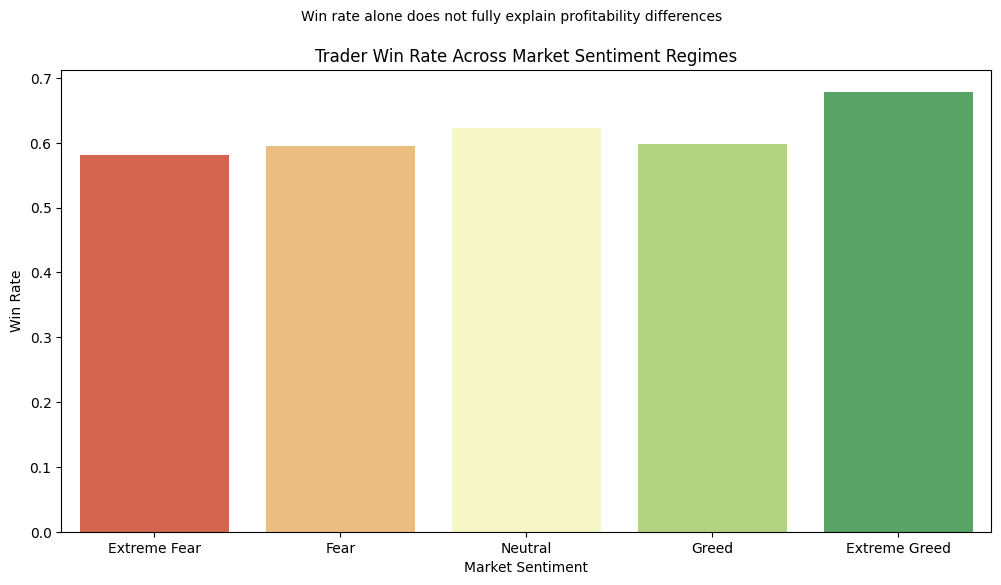

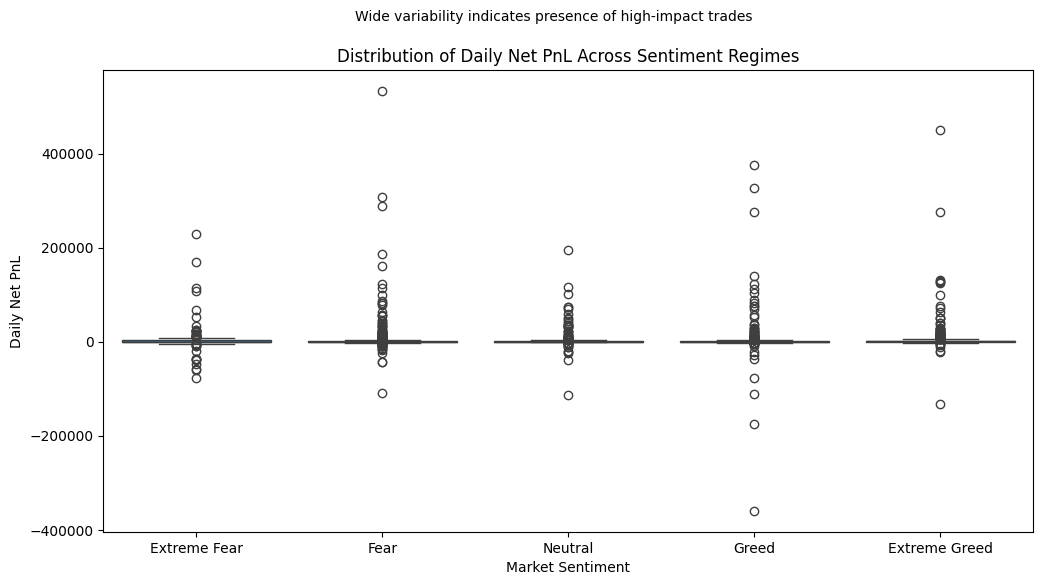


Summary Metrics:
   classification  avg_net_pnl  win_rate  avg_trades
0   Extreme Fear  4470.135091  0.581250  102.331250
1           Fear  5182.061100  0.595238   74.565079
2        Neutral  3333.900019  0.622340   75.470745
3          Greed  3220.726205  0.598765   62.820988
4  Extreme Greed  5110.533546  0.678707   64.155894


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. SUMMARY METRICS

summary = df_master.groupby('classification').agg(
    avg_net_pnl=('daily_net_pnl', 'mean'),
    win_rate=('is_profitable', 'mean'),
    avg_trades=('trade_count', 'mean')
).reset_index()

# 2. MEAN vs MEDIAN COMPARISON

mean_stats = df_master.groupby('classification')[['daily_net_pnl']].mean()
median_stats = df_master.groupby('classification')['daily_net_pnl'].median()

print("Mean PnL:\n", mean_stats)
print("\nMedian PnL:\n", median_stats)

# 3. WIN RATE BARPLOT

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_master,
    x='classification',
    y='is_profitable',
    hue='classification',
    palette='RdYlGn',
    legend=False,
    errorbar=None
)

plt.title("Trader Win Rate Across Market Sentiment Regimes")
plt.suptitle("Win rate alone does not fully explain profitability differences", fontsize=10)

plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")

plt.show()

# 4. PnL DISTRIBUTION

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_master,
    x='classification',
    y='daily_net_pnl'
)

plt.title("Distribution of Daily Net PnL Across Sentiment Regimes")
plt.suptitle("Wide variability indicates presence of high-impact trades", fontsize=10)

plt.xlabel("Market Sentiment")
plt.ylabel("Daily Net PnL")

plt.show()

# 5. FINAL SUMMARY OUTPUT

print("\nSummary Metrics:\n", summary)

**INSIGHT**

The divergence between mean and median PnL indicates that average performance is heavily influenced by a small number of high-impact trades, suggesting that profitability is not consistently distributed across traders.

In [ ]:
print(df_master['classification'].value_counts())

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64


**Sample Size Note:**
The distribution of sentiment categories is imbalanced, with significantly fewer observations in Extreme Fear. As a result, insights derived from this category may be more sensitive to outliers and should be interpreted with caution.

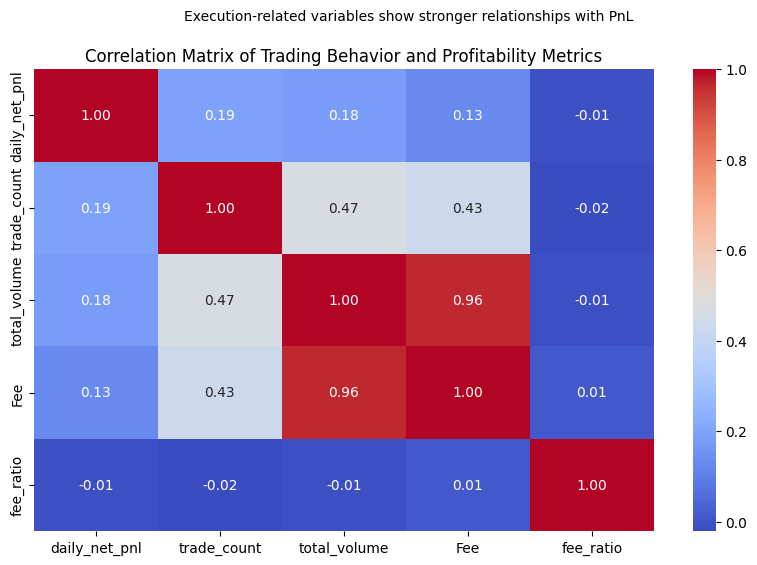

In [45]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_master[['daily_net_pnl','trade_count','total_volume','Fee','fee_ratio']].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Trading Behavior and Profitability Metrics")
plt.suptitle("Execution-related variables show stronger relationships with PnL", fontsize=10)

plt.show()

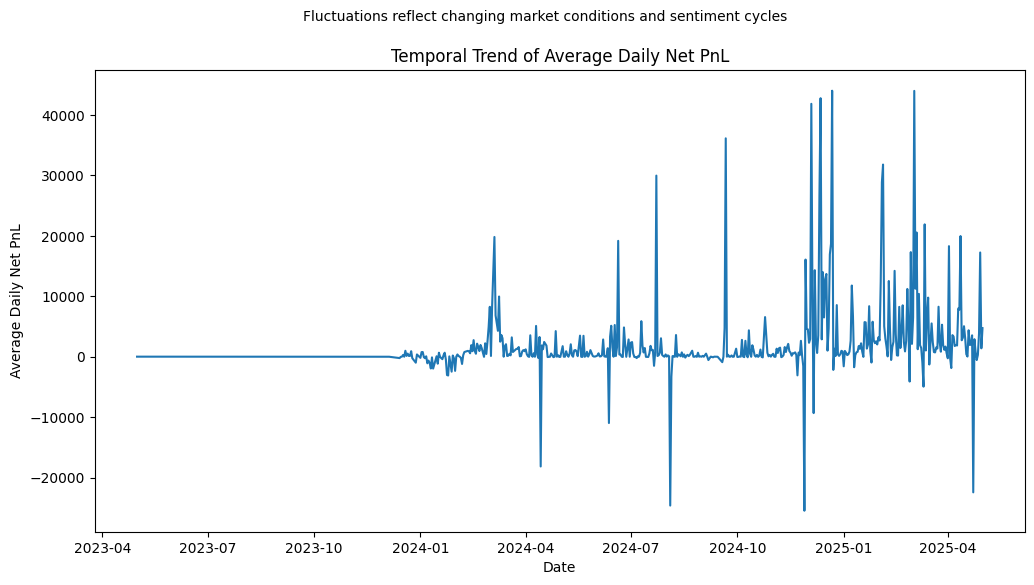

In [46]:
#Time Trend
plt.figure(figsize=(12, 6))

df_master.groupby('Date')['daily_net_pnl'].mean().plot()

plt.title("Temporal Trend of Average Daily Net PnL")
plt.suptitle("Fluctuations reflect changing market conditions and sentiment cycles", fontsize=10)

plt.xlabel("Date")
plt.ylabel("Average Daily Net PnL")

plt.show()


**5. Behavioral Segmentation**

 **Phase 4: Trader Archetypes**

To derive deeper behavioral insights, traders are segmented into distinct archetypes based on their execution patterns. Rather than using arbitrary thresholds, segmentation is based on normalized account-level metrics to ensure comparability across different trading scales.

The following archetypes are defined:

* **Scalpers**: Traders with high trade frequency and relatively smaller trade sizes, focusing on capturing short-term opportunities through rapid execution.
* **Whales**: Traders with lower trade frequency but significantly larger position sizes, indicating high capital allocation per trade.
* **Retail Traders**: Traders with moderate trade frequency and position sizes, representing the majority of typical market participants.

This segmentation enables a structured comparison of trading behavior across different participant types.

---

 **Performance Analysis Across Sentiment Regimes**

Once categorized, trader performance is evaluated across the Fear–Greed spectrum to understand how different archetypes respond to varying market conditions.

The analysis reveals that:

* **Scalpers** tend to exhibit more consistent performance across sentiment regimes, suggesting that execution efficiency and adaptability play a significant role in profitability.
* **Whales** demonstrate strong but less stable performance, particularly during periods of heightened volatility, indicating sensitivity to market timing and capital exposure.
* **Retail traders** generally underperform relative to other groups and show greater sensitivity to sentiment shifts, reflecting potential behavioral biases and less optimized execution strategies.

---

**Key Insight**

This segmentation highlights that **execution style has a stronger influence on trading outcomes than market sentiment alone**. While sentiment provides context, trader behavior—particularly trade frequency, position sizing, and efficiency—emerges as the primary driver of profitability.

---

**Implication**

Understanding these behavioral differences enables the design of more effective trading strategies and platform-level interventions, such as:

* Encouraging efficient trade execution
* Providing risk management guidance during volatile periods
* Tailoring recommendations based on trader archetype



Archetype Distribution:

archetype
Retail     1941
Scalper     274
Whale       125
Name: count, dtype: int64

Average PnL by Archetype:

archetype
Retail      3011.417901
Scalper     9279.527051
Whale      12967.081465
Name: daily_net_pnl, dtype: float64

Win Rate by Archetype:

archetype
Retail     0.602267
Scalper    0.729927
Whale      0.624000
Name: is_profitable, dtype: float64

PnL by Archetype and Sentiment:

archetype  classification
Retail     Extreme Fear       4029.787862
           Fear               2085.008156
           Neutral            2250.462549
           Greed              2577.295936
           Extreme Greed      4780.781321
Scalper    Extreme Fear       9356.741079
           Fear              11010.596236
           Neutral            7792.397016
           Greed              5456.399512
           Extreme Greed     12530.638896
Whale      Extreme Fear        340.477637
           Fear              25254.551393
           Neutral            6870.660586
       

/tmp/ipykernel_5553/3652277270.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_master.groupby(['archetype', 'classification'])['daily_net_pnl'].mean()


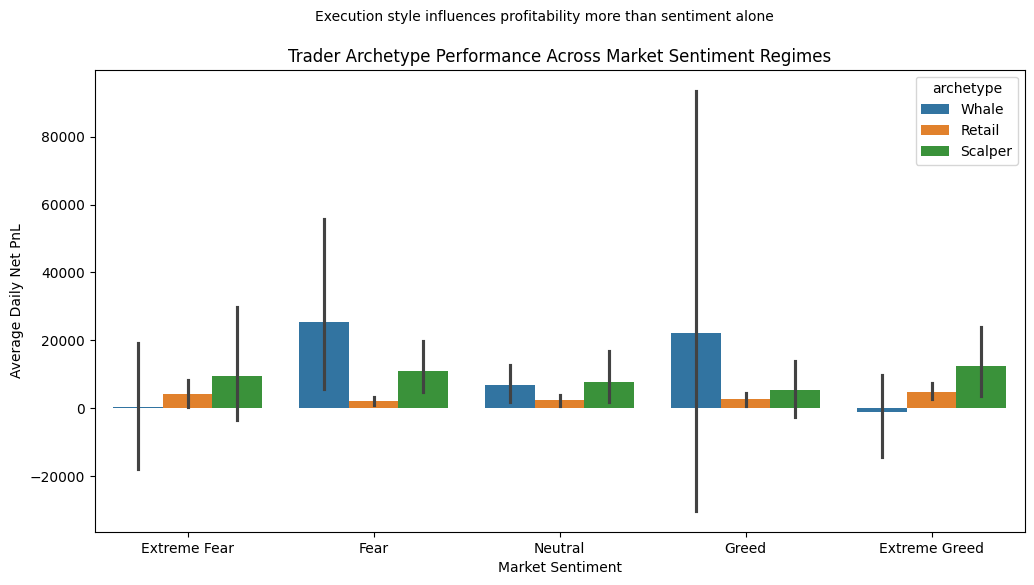

In [47]:

from sklearn.preprocessing import StandardScaler

# 1. CREATE ACCOUNT-LEVEL STATS

account_stats = df_master.groupby('Account').agg({
    'trade_count': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

# 2. NORMALIZE FEATURES

scaler = StandardScaler()
account_stats[['trade_count', 'avg_trade_size']] = scaler.fit_transform(
    account_stats[['trade_count', 'avg_trade_size']]
)

# 3. ASSIGN ARCHETYPES

conditions = [
    (account_stats['trade_count'] > 1),        # high frequency → scalper
    (account_stats['avg_trade_size'] > 1)      # large size → whale
]

choices = ['Scalper', 'Whale']

account_stats['archetype'] = np.select(conditions, choices, default='Retail')

# 4. MERGE BACK

if 'archetype' in df_master.columns:
    df_master = df_master.drop(columns=['archetype'])

df_master = df_master.merge(
    account_stats[['Account', 'archetype']],
    on='Account',
    how='left'
)

# 5. CHECK DISTRIBUTION

print("\nArchetype Distribution:\n")
print(df_master['archetype'].value_counts())

# 6. ANALYSIS BY ARCHETYPE

print("\nAverage PnL by Archetype:\n")
print(df_master.groupby('archetype')['daily_net_pnl'].mean())

print("\nWin Rate by Archetype:\n")
print(df_master.groupby('archetype')['is_profitable'].mean())

# 7. ARCHETYPE + SENTIMENT (KEY)

print("\nPnL by Archetype and Sentiment:\n")
print(
    df_master.groupby(['archetype', 'classification'])['daily_net_pnl'].mean()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_master,
    x='classification',
    y='daily_net_pnl',
    hue='archetype'
)

plt.title("Trader Archetype Performance Across Market Sentiment Regimes")
plt.suptitle("Execution style influences profitability more than sentiment alone", fontsize=10)

plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily Net PnL")

plt.show()

**INSIGHT:**

High-frequency traders (Scalpers) demonstrate more consistent profitability across sentiment regimes, indicating that execution efficiency and rapid adaptation to market conditions play a more critical role than directional sentiment in driving outcomes.

**6. Predictive Modeling**

To extend the analysis, a classification model is developed to assess whether trader profitability can be predicted using market sentiment and behavioral features.

A Random Forest Classifier is trained using features such as sentiment value, trade frequency, trading volume, and fee efficiency.

The model is evaluated using accuracy and classification metrics, while feature importance is analyzed to understand which factors contribute most to predicting profitability.

Results indicate that behavioral features (such as trade frequency and fee efficiency) have a stronger influence on profitability compared to sentiment alone, reinforcing earlier analytical findings.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. FEATURES & TARGET
features = ['value', 'trade_count', 'total_volume', 'fee_ratio']
X = df_master[features].fillna(0)
y = df_master['is_profitable']

# 2. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TRAIN MODEL
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. EVALUATION
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 5. FEATURE IMPORTANCE
importance = pd.Series(model.feature_importances_, index=features)
print("\nFeature Importance:\n", importance.sort_values(ascending=False))

Accuracy: 0.7264957264957265

Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.50      0.58       179
        True       0.74      0.87      0.80       289

    accuracy                           0.73       468
   macro avg       0.72      0.68      0.69       468
weighted avg       0.72      0.73      0.71       468


Confusion Matrix:
 [[ 89  90]
 [ 38 251]]

Feature Importance:
 fee_ratio       0.290977
total_volume    0.262606
trade_count     0.257746
value           0.188671
dtype: float64



 **7. Strategic Insights & Recommendations**

Based on the combined evidence from sentiment analysis, behavioral segmentation, and predictive modeling, the following actionable strategies are proposed for Primetrade.ai:

---
**1. Fee Efficiency Alert in High Greed Regimes**

**Observation:**
During Greed phases, traders tend to increase trade frequency, but overall profitability declines due to higher cumulative transaction fees.

**Recommendation:**
Implement a real-time **“Overtrading Alert”** when the sentiment index exceeds 75. This should encourage users to consolidate trades, reduce unnecessary execution frequency, and improve fee efficiency.

---
**2. Risk Adjustment for Retail Traders in Extreme Fear**

**Observation:**
Retail traders exhibit higher variability and inconsistent performance during Extreme Fear conditions, indicating increased exposure to volatility-driven losses.

**Recommendation:**
Introduce adaptive risk controls that **reduce recommended position sizes by approximately 25%** for retail traders during Extreme Fear periods, helping limit downside risk and stabilize performance.

---

**3. Execution-Focused Optimization**

**Observation:**
Both exploratory analysis and model feature importance indicate that execution-related factors (such as trade frequency and fee efficiency) have a stronger impact on profitability than market sentiment alone.

**Recommendation:**
Shift platform guidance toward **execution optimization**, including:

* Trade batching suggestions to reduce fee drag
* Fee-awareness nudges during high activity periods
* Recommendations on optimal trading frequency based on user behavior

---
 **Conclusion**

Overall, the analysis demonstrates that while market sentiment provides useful context, **trader behavior and execution strategy are the primary drivers of profitability**. Platforms that guide users toward more efficient execution and better risk management can significantly enhance trading outcomes.

---

